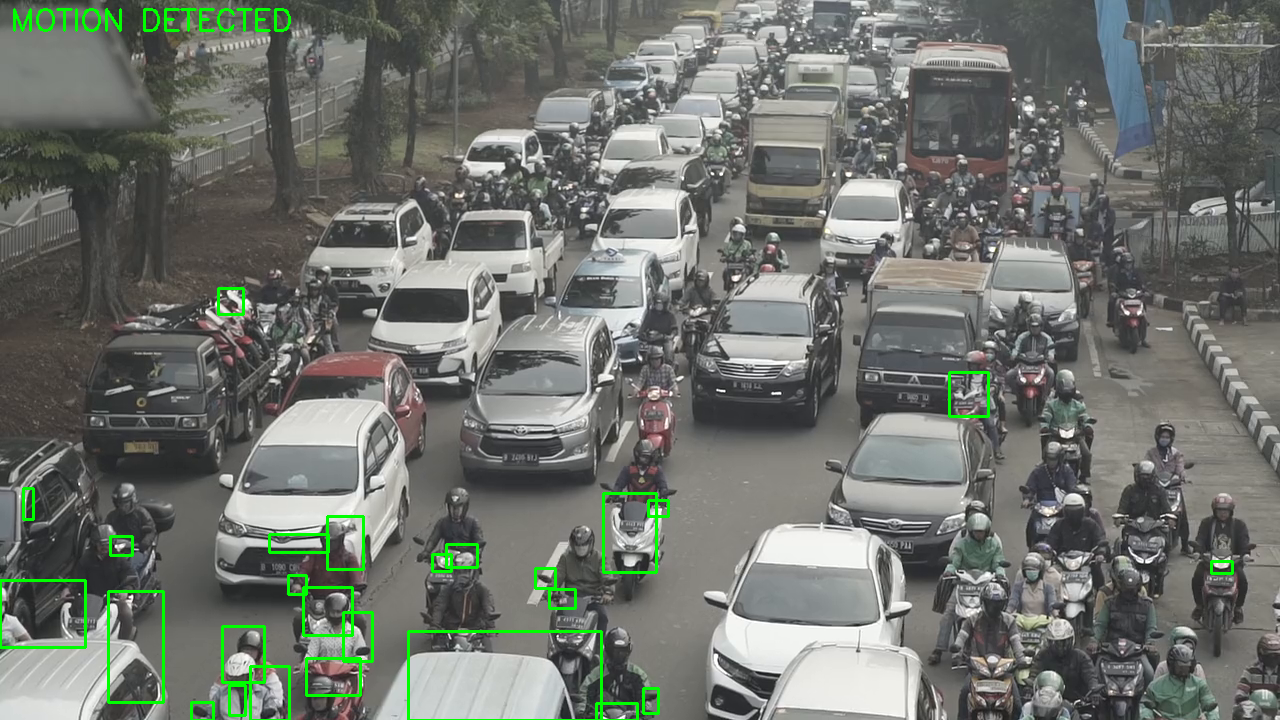

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load video
cap = cv2.VideoCapture('/content/t1.mp4')

# Read two frames
ret1, frame1 = cap.read()
ret2, frame2 = cap.read()
/
if not ret1 or not ret2:
    print("Error reading video")
else:
    # Convert to grayscale
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Blur
    gray1 = cv2.GaussianBlur(gray1, (15, 15), 0)
    gray2 = cv2.GaussianBlur(gray2, (15, 15), 0)

    # Difference
    diff = cv2.absdiff(gray1, gray2)

    # Threshold
    thresh = cv2.threshold(diff, 15, 255, cv2.THRESH_BINARY)[1]

    # Dilate
    thresh = cv2.dilate(thresh, None, iterations=3)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    motion_detected = False

    # Draw rectangles
    for contour in contours:
        if cv2.contourArea(contour) > 200:
            motion_detected = True
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(frame2, (x, y), (x+w, y+h), (0,255,0), 2)

    # ✅ Add text on image
    if motion_detected:
        text = "MOTION DETECTED"
        color = (0, 255, 0)
    else:
        text = "NO MOTION"
        color = (0, 0, 255)

    cv2.putText(frame2, text, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # Show final output
    cv2_imshow(frame2)

cap.release()

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 19 persons, 19 cars, 3 motorcycles, 2 buss, 323.6ms
Speed: 7.8ms preprocess, 323.6ms inference, 37.2ms postprocess per image at shape (1, 3, 384, 640)


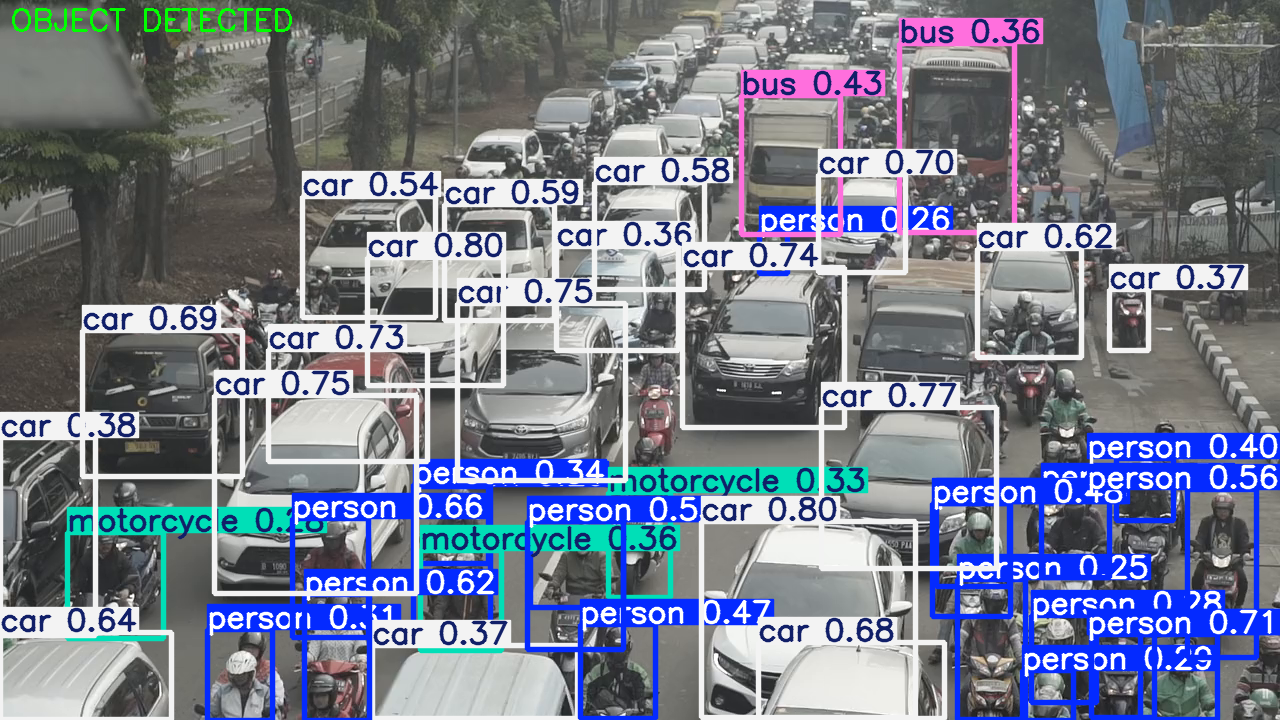

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2

# Load YOLO model
model = YOLO("yolov8n.pt")

# Load video
cap = cv2.VideoCapture('/content/t1.mp4')

# Read ONLY one frame
ret, frame = cap.read()

if not ret:
    print("Error reading video")
else:
    # Run YOLO detection
    results = model(frame)

    # Get output image with boxes
    output = results[0].plot()

    # ✅ Add text for record
    cv2.putText(output, "OBJECT DETECTED", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    # Show final single image
    cv2_imshow(output)

cap.release()